In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as scp
import uproot
import matplotlib
font = {'weight' : 'bold',
        'size'   : 15}

matplotlib.rc('font', **font)

In [3]:
### Opticks Nexus Analysis

import h5py

In [4]:
def GetInfo(filePath):
    Values={}
    f=h5py.File(filePath,"r")
    Values["Timing/photons"]=np.array(f["MC"]["Timing"]["photons"])
    Values["Timing/time"]=np.array(f["MC"]["Timing"]["time"])
    Values["Timing/event_id"]=np.array(f["MC"]["Timing"]["event_id"])

    try:
        Values["Opticks_Hits/event_id"]=np.array(f["MC"]["Opticks_Hits"]["event_id"])
        Values["Opticks_Hits/x"]=np.array(f["MC"]["Opticks_Hits"]["x"])
        Values["Opticks_Hits/y"]=np.array(f["MC"]["Opticks_Hits"]["y"])
        Values["Opticks_Hits/z"]=np.array(f["MC"]["Opticks_Hits"]["z"])
        Values["Opticks_Hits/time"]=np.array(f["MC"]["Opticks_Hits"]["time"])
        Values["Opticks_Hits/boundary"]=np.array(f["MC"]["Opticks_Hits"]["boundary"])
    except:
        print("No Opticks_Hits")
        try:
            Values["GEANT4_Optical_Hits/event_id"]=np.array(f["MC"]["GEANT4_Optical_Hits"]["event_id"])
            Values["GEANT4_Optical_Hits/name"]=np.array(f["MC"]["GEANT4_Optical_Hits"]["name"])
            Values["GEANT4_Optical_Hits/x"]=np.array(f["MC"]["GEANT4_Optical_Hits"]["x"])
            Values["GEANT4_Optical_Hits/y"]=np.array(f["MC"]["GEANT4_Optical_Hits"]["y"])
            Values["GEANT4_Optical_Hits/z"]=np.array(f["MC"]["GEANT4_Optical_Hits"]["z"])
            Values["GEANT4_Optical_Hits/time"]=np.array(f["MC"]["GEANT4_Optical_Hits"]["time"])
        except:
            print("No GEANT4_Optical_Hits")
            return Values

    return Values

In [5]:
### Other Performance Results
Hits=GetInfo("/home/argon/Desktop/hits.h5")


In [6]:
print(Hits)

{'Timing/photons': array([ 17756405,  77840207, 148123205, 133719484,  50157146]), 'Timing/time': array([1.09074411, 4.72056964, 8.94995058, 8.07855305, 3.0248673 ]), 'Timing/event_id': array([0, 1, 2, 3, 4]), 'Opticks_Hits/event_id': array([0, 0, 0, ..., 4, 4, 4]), 'Opticks_Hits/x': array([-3.1998408,  1.2824906,  4.4593663, ...,  4.886471 ,  2.057107 ,
        2.086584 ], dtype=float32), 'Opticks_Hits/y': array([-1.6840315, -3.5665164, -6.9952073, ..., -9.55519  ,  4.318702 ,
       -5.6273146], dtype=float32), 'Opticks_Hits/z': array([-251.36111, -251.39969, -253.11845, ..., -254.75511, -251.6567 ,
       -252.06114], dtype=float32), 'Opticks_Hits/time': array([6.68372116e+01, 2.71543617e+01, 1.12206963e+02, ...,
       1.11953992e+05, 1.12491414e+05, 1.12429812e+05], dtype=float32), 'Opticks_Hits/boundary': array([33, 33, 33, ..., 33, 33, 33], dtype=uint32)}


In [7]:

def EventSummary(key,Event,data,isPrint=True,boundaries=[30,33]):
    if(Event==-1):
        EventLength=len(data["Timing/photons"])
        PMTHits_=np.array([])
        CameraHits_=np.array([])
        for evt in range(0,EventLength):
            EventHitMask=data[f"{key}/event_id"]==evt
            #PhotonCountEventMask=data["Timing/event_id"]==evt
            #TotalPhoton=data["Timing/photons"][PhotonCountEventMask][0]
            #ExecutionTime=data["Timing/time"][PhotonCountEventMask][0]

            if(key=="Opticks_Hits"):
                tool="Opticks"
                CamHitMask=data[f"{key}/boundary"][EventHitMask]==boundaries[0]
                PMTHitMask=data[f"{key}/boundary"][EventHitMask]==boundaries[1]
                CameraHits=len(data[f"{key}/boundary"][EventHitMask][CamHitMask])
                PMTHits=len(data[f"{key}/boundary"][EventHitMask][PMTHitMask])
            else:
                tool="G4"
                CamHitMask=data[f"{key}/name"][EventHitMask]==b'camWindow'
                PMTHitMask=data[f"{key}/name"][EventHitMask]==b'PHOTOCATHODE'
                CameraHits=len(data[f"{key}/name"][EventHitMask][CamHitMask])
                PMTHits=len(data[f"{key}/name"][EventHitMask][PMTHitMask])
            PMTHits_=np.append(PMTHits_,PMTHits)
            CameraHits_=np.append(CameraHits_,CameraHits)
        return PMTHits_,CameraHits_     
    
    else:
        EventHitMask=data[f"{key}/event_id"]==Event
        PhotonCountEventMask=data["Timing/event_id"]==Event
        TotalPhoton=data["Timing/photons"][PhotonCountEventMask][0]
        ExecutionTime=data["Timing/time"][PhotonCountEventMask][0]

        if(key=="Opticks_Hits"):
            tool="Opticks"
            CamHitMask=data[f"{key}/boundary"][EventHitMask]==boundaries[0]
            PMTHitMask=data[f"{key}/boundary"][EventHitMask]==boundaries[1]
            CameraHits=len(data[f"{key}/boundary"][EventHitMask][CamHitMask])
            PMTHits=len(data[f"{key}/boundary"][EventHitMask][PMTHitMask])
            PMTX=data[f"{key}/x"][EventHitMask][PMTHitMask]
            PMTY=data[f"{key}/y"][EventHitMask][PMTHitMask]
            PMTZ=data[f"{key}/z"][EventHitMask][PMTHitMask]
            CamX=data[f"{key}/x"][EventHitMask][CamHitMask]
            CamY=data[f"{key}/y"][EventHitMask][CamHitMask]
            CamZ=data[f"{key}/z"][EventHitMask][CamHitMask]
        else:
            tool="G4"
            CamHitMask=data[f"{key}/name"][EventHitMask]==b'camWindow'
            PMTHitMask=data[f"{key}/name"][EventHitMask]==b'PHOTOCATHODE'
            CameraHits=len(data[f"{key}/name"][EventHitMask][CamHitMask])
            PMTHits=len(data[f"{key}/name"][EventHitMask][PMTHitMask])
            PMTX=data[f"{key}/x"][EventHitMask][PMTHitMask]
            PMTY=data[f"{key}/y"][EventHitMask][PMTHitMask]
            PMTZ=data[f"{key}/z"][EventHitMask][PMTHitMask]
            CamX=data[f"{key}/x"][EventHitMask][CamHitMask]
            CamY=data[f"{key}/y"][EventHitMask][CamHitMask]
            CamZ=data[f"{key}/z"][EventHitMask][CamHitMask]
        
        if(isPrint):    
            print(f"------------------------ Event {Event} ({tool})------------------------")
            print(f"CameraHits  :  {CameraHits}       , PMTHits {PMTHits}")
            print(f"------------------------------------------------")
            print(f"TotalPhoton :  {TotalPhoton}   , Executation Time {ExecutionTime}")
        
        return np.array([TotalPhoton,ExecutionTime,PMTHits,CameraHits]),[PMTX,PMTY,PMTZ],[CamX,CamY,CamZ]
    
    
def GetDistributions(runs,key,bnd=[30,33]):
    Values={}
    Values["Photon"]=np.array([])
    Values["ExecutionTime"]=np.array([])
    Values["PMTHits"]=np.array([])
    Values["CameraHits"]=np.array([])

    for run in runs:
        ## Combine All the Photons and times
        Values["Photon"]=np.hstack((Values["Photon"],run['Timing/photons']))
        Values["ExecutionTime"]=np.hstack((Values["ExecutionTime"],run['Timing/time']))
        Results=EventSummary(key,-1,run,isPrint=True,boundaries=bnd)
        Values["PMTHits"]=np.hstack((Values["PMTHits"],Results[0]))
        Values["CameraHits"]=np.hstack((Values["CameraHits"],Results[1]))
        
    return Values    

------------------------ Event 3 (Opticks)------------------------
CameraHits  :  20453       , PMTHits 105543
------------------------------------------------
TotalPhoton :  133719484   , Executation Time 8.07855305
[302.15 302.15 302.15 ... 302.15 302.15 302.15]


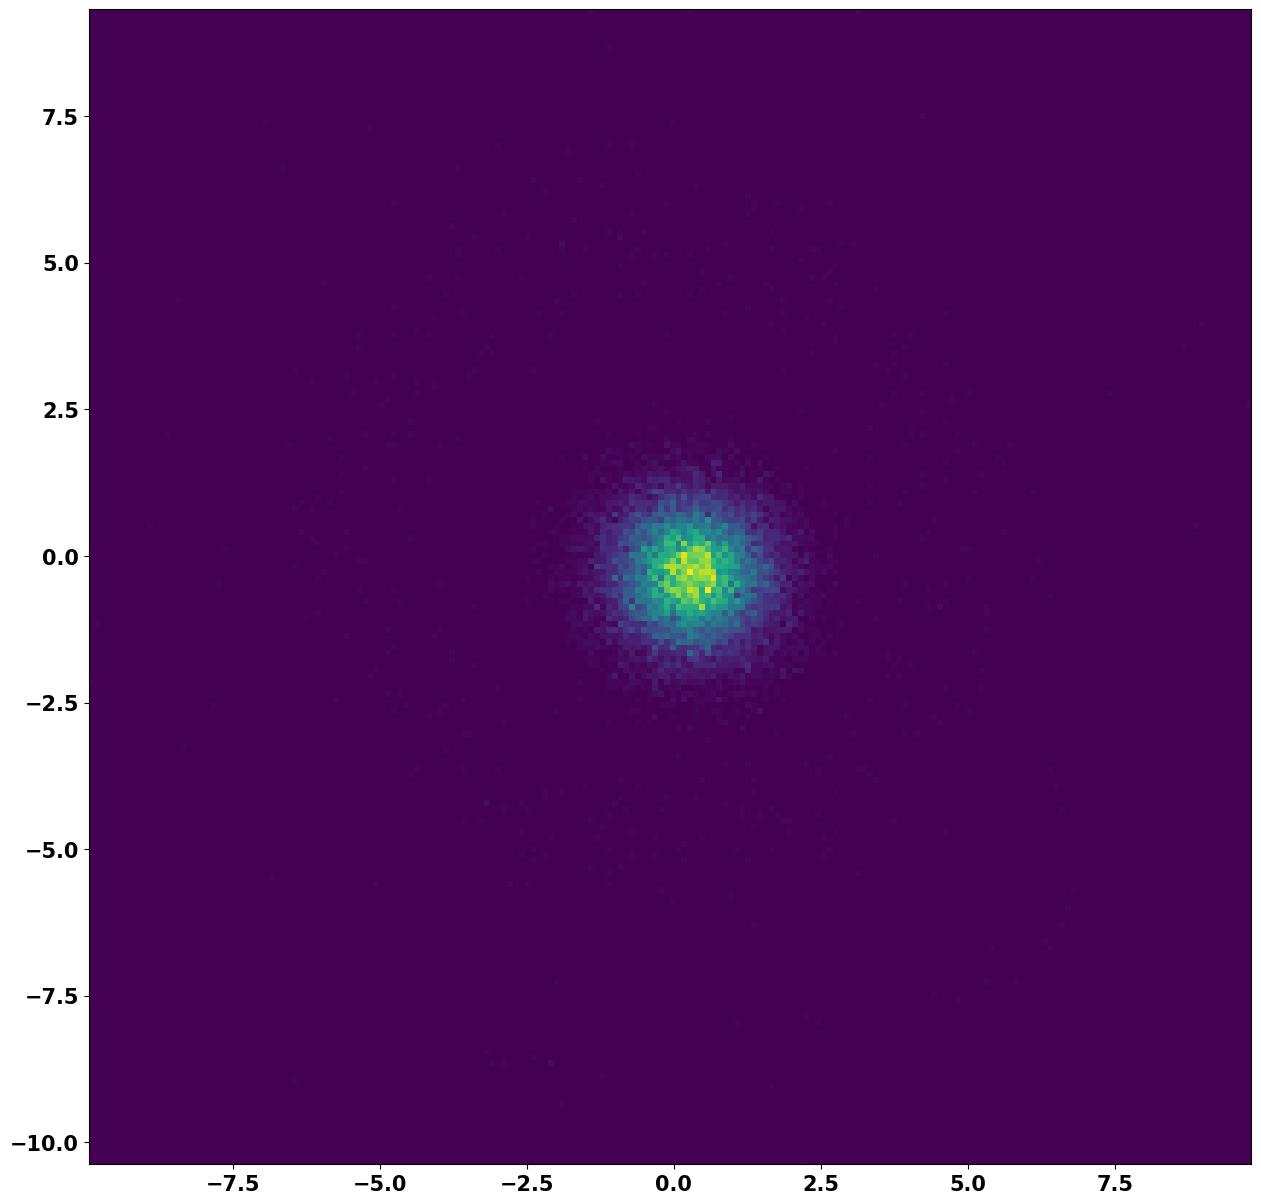

In [19]:
EvntSummary1=EventSummary("Opticks_Hits",3,Hits)

plt.figure(figsize=(15,15))
_=plt.hist2d(EvntSummary1[2][0],EvntSummary1[2][1],bins=200)
print(EvntSummary1[2][2])